In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None) 

In [ ]:
df = pd.read_csv("files/world_data_full_apply_nulos.csv", index_col=0)
df.head(2).T

,0,1
country,Afghanistan,Albania
density,60.0,105.0
abbreviation,AF,AL
agricultural_land,58.1,43.1
land_area,652.23,28.748
armed_forces_size,323.0,9.0
birth_rate,32.49,11.78
calling_code,93.0,355.0
capital/major_city,Kabul,Tirana
co2-emissions,8.672,4.536


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 36 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   country                               195 non-null    str    
 1   density                               195 non-null    float64
 2   abbreviation                          188 non-null    str    
 3   agricultural_land                     188 non-null    float64
 4   land_area                             165 non-null    float64
 5   armed_forces_size                     166 non-null    float64
 6   birth_rate                            189 non-null    float64
 7   calling_code                          194 non-null    float64
 8   capital/major_city                    192 non-null    str    
 9   co2-emissions                         183 non-null    float64
 10  cpi                                   175 non-null    float64
 11  cpi_change                    

Todas deben llevar título.

Los nombres de los ejes deben estar en castellano.

En los scatterplot los puntos deben tener un tamaño de 2.

En los scatterplot los puntos deben tener un color diferente al azul.

En los barplot las barras siempre tienen que estar ordenadas de mayor a menor.

En los barplot y countplot las barras tienen que tener un color diferente a los que vienen por defecto.

En los pieplot siempre tenemos que añadir la etiqueta de a que % corresponde cada quesito.

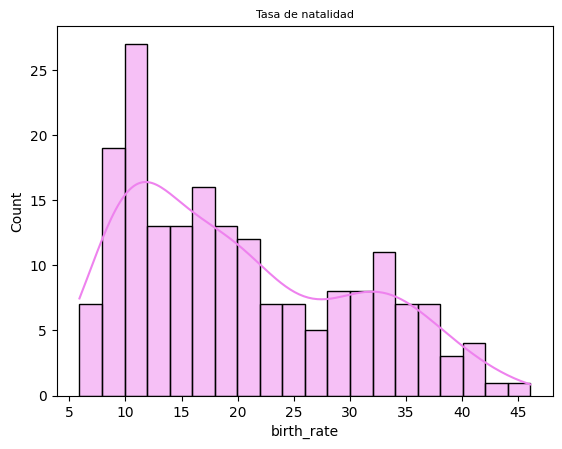

In [ ]:
# 1 ¿Cómo se distribuye la tasa de natalidad en el conjunto de datos? ¿Hay algún patrón evidente?

sns.histplot(x = "birth_rate", 
             data = df, 
             color = "violet", 
             kde = True, 
             bins = 20);

plt.title("Tasa de natalidad", fontsize = 8);

# La distribución de la tasa de natalidad está sesgada a la derecha, con la mayoría de países concentrados entre 10 y 20 nacimientos por cada 1.000 habitantes. Se observa una cola hacia valores altos, lo que indica la presencia de países con tasas de natalidad elevadas. Además, se aprecia un posible segundo pico en valores altos, lo que podría sugerir la existencia de distintos grupos de países según su nivel de natalidad.

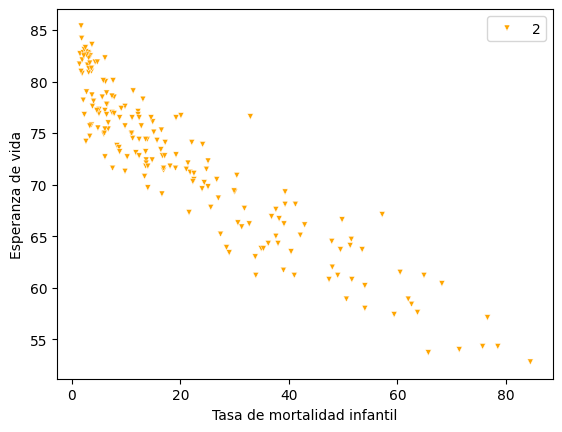

In [ ]:
# 2 ¿Existe una relación aparente entre la tasa de mortalidad infantil y la esperanza de vida? Proporciona una breve descripción de los patrones que observes.

sns.scatterplot(x = "infant_mortality", 
                y = "life_expectancy", 
                data = df, 
                size = 2, 
                marker= "v", 
                color = "orange")

# cambiamos los nombres de los ejes
plt.xlabel("Tasa de mortalidad infantil")
plt.ylabel("Esperanza de vida");

# Se observa una relación negativa entre la tasa de mortalidad infantil y la esperanza de vida. A medida que aumenta la mortalidad infantil, la esperanza de vida disminuye. Es un patrón lineal.

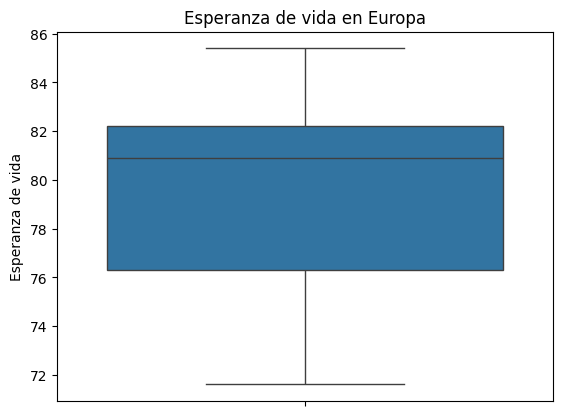

count    43.000000
mean     79.202326
std       3.621266
min      71.600000
25%      76.300000
50%      80.900000
75%      82.200000
max      85.400000
Name: life_expectancy, dtype: float64

In [ ]:
# 3 ¿Cuál es la mediana de la esperanza de vida en Europa? Proporciona un rango intercuartil aproximado y verifica si existen valores atípicos.

europa = df[df["continent"] == "Europe"]

sns.boxplot(y="life_expectancy", data=europa)

plt.title("Esperanza de vida en Europa")
plt.ylabel("Esperanza de vida")

plt.show()

europa["life_expectancy"].describe()

# La mediana de esperanza de vida en Europa es de 81 años. No hay outliers.
# Respecto a rangos intercuantiles, podemos afirmar que el 25% de la población no alcanzaría los 77 años, mientras que el 75% no alcanza los 83.

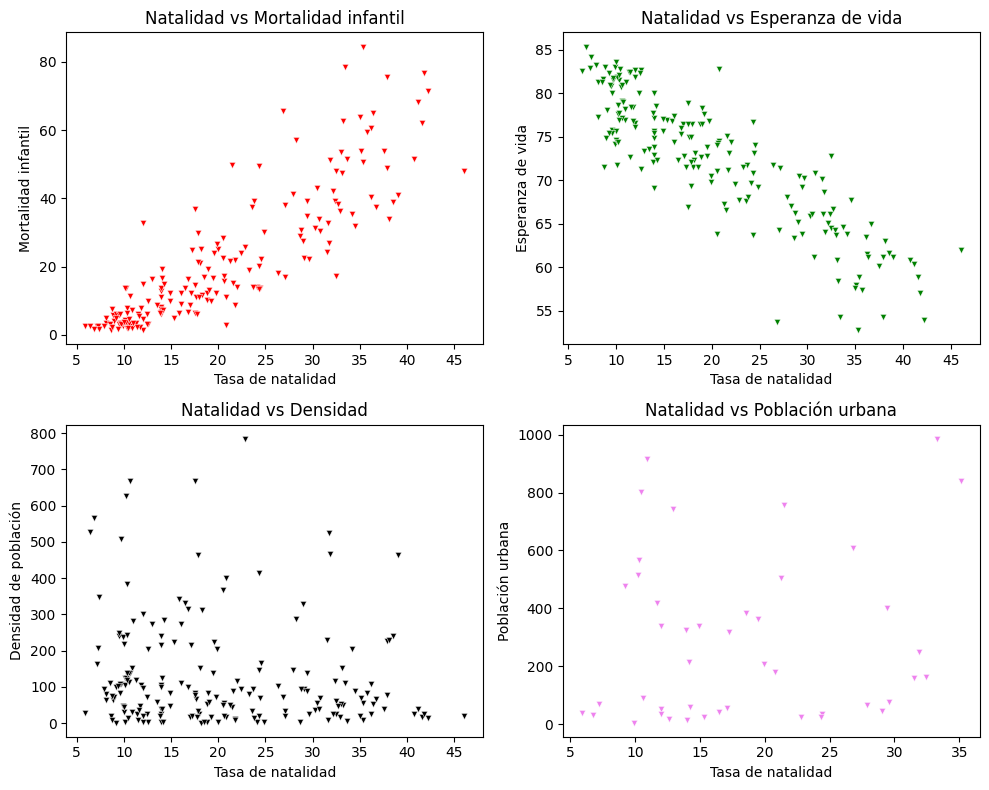

In [ ]:
# 4 ¿Existen relaciones visibles entre la tasa de natalidad y las siguientes variables: tasa de mortalidad infantil, esperanza de vida, densidad de población y población urbana? Usa un subplot. Describe cualquier patrón que encuentres.

fig, axes = plt.subplots(2, 2, figsize=(10, 8)) # Creamos un subplot

# 1 natalidad vs mortalidad infantil
sns.scatterplot(
    ax=axes[0, 0],
    x="birth_rate",
    y="infant_mortality",
    data=df,
    color="red",
    s=20,
    marker="v"
)
# Mantenemos los ejes
axes[0, 0].set_title("Natalidad vs Mortalidad infantil")
axes[0, 0].set_xlabel("Tasa de natalidad")
axes[0, 0].set_ylabel("Mortalidad infantil")

# 2 natalidad vs esperanza de vida
sns.scatterplot(
    ax=axes[0, 1],
    x="birth_rate",
    y="life_expectancy",
    data=df,
    color="green",
    s=20,
    marker="v"
)
# Mantenemos los ejes
axes[0, 1].set_title("Natalidad vs Esperanza de vida")
axes[0, 1].set_xlabel("Tasa de natalidad")
axes[0, 1].set_ylabel("Esperanza de vida")

# 3 natalidad vs densidad
sns.scatterplot(
    ax=axes[1, 0],
    x="birth_rate",
    y="density",
    data=df,
    color="black",
    s=20,
    marker="v"
)
# Mantenemos los ejes
axes[1, 0].set_title("Natalidad vs Densidad")
axes[1, 0].set_xlabel("Tasa de natalidad")
axes[1, 0].set_ylabel("Densidad de población")

# 4 natalidad vs población urbana
sns.scatterplot(
    ax=axes[1, 1],
    x="birth_rate",
    y="urban_population",
    data=df,
    color="violet",
    s=20,
    marker="v"
)
# Mantenemos los ejes
axes[1, 1].set_title("Natalidad vs Población urbana")
axes[1, 1].set_xlabel("Tasa de natalidad")
axes[1, 1].set_ylabel("Población urbana")

plt.tight_layout()
plt.show()

# Se observa que la tasa de natalidad presenta una relación positiva con la mortalidad infantil, ya que ambas tienden a aumentar conjuntamente. Por el contrario, existe una relación negativa con la esperanza de vida, donde mayores tasas de natalidad se asocian con menor esperanza de vida. En cuanto a la población urbana, se aprecia una tendencia negativa, indicando que los países más urbanizados suelen tener menor natalidad. La densidad de población no muestra un patrón claro.